In [43]:
import numpy as np
import scipy as sp
import soundfile as sf
import torch
import torch.nn as nn

data, samplerate = sf.read('data/train_audio/grekis/XC170448.ogg')
print(data.shape)
print(samplerate)
print(data[:10])
print(len(data)/samplerate)


(761088,)
32000
[ 6.15174713e-06 -5.48686012e-06  1.55499237e-07  2.45148749e-05
  4.27384066e-06 -4.32946626e-06  7.49957735e-06 -3.83278439e-06
  3.89413162e-06 -5.83169685e-06]
23.784


In [40]:
fourier = np.fft.rfft(data)
print(fourier.shape)
print(fourier.real[:10])

(380545,)
[-7.78684970e-04 -9.70951199e-04 -9.12518817e-04 -1.01235387e-03
  5.48732272e-04 -1.24488837e-04 -7.23494781e-04  4.72874240e-04
  5.71622298e-04 -5.47524870e-05]


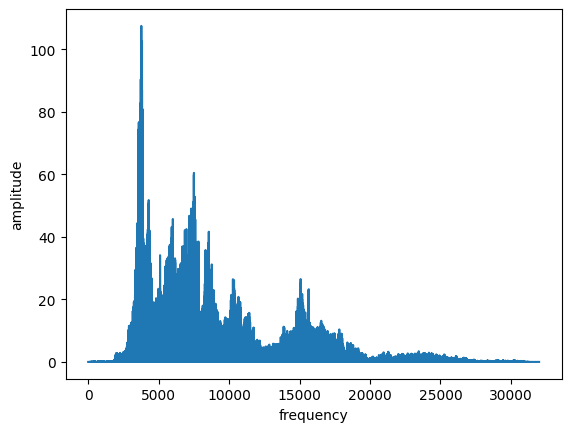

In [41]:
import matplotlib.pyplot as plt

w = np.linspace(0, samplerate, len(fourier))
fourier_to_plot = np.abs(fourier.real)

plt.plot(w, fourier_to_plot)
plt.xlabel('frequency')
plt.ylabel('amplitude')
plt.show()

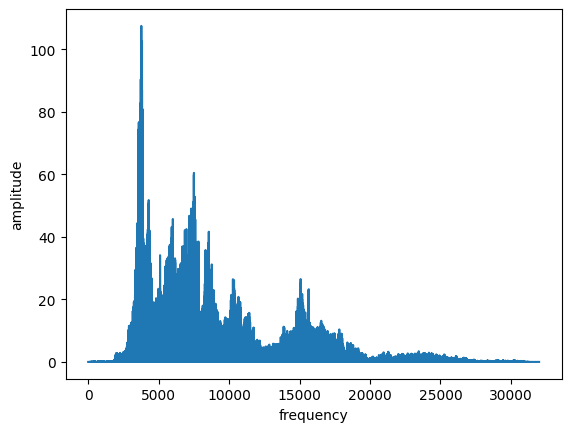

In [42]:
# compute frequency associated
# with coefficients
freqs = np.fft.rfftfreq(len(data), d=1/samplerate)
plt.plot(freqs*2, fourier_to_plot)    
plt.xlabel('frequency')
plt.ylabel('amplitude')
plt.show()

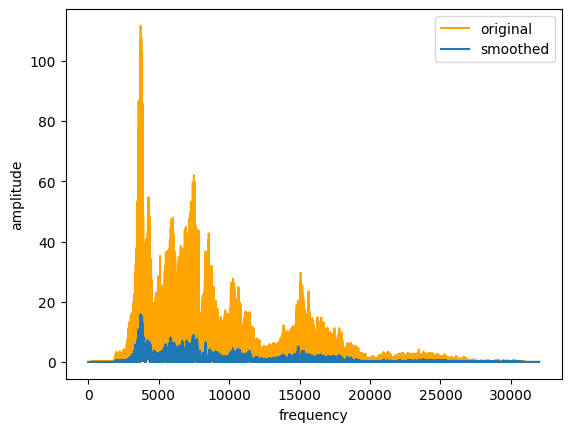

In [32]:
from scipy.ndimage import gaussian_filter1d

smoothed_fourier = gaussian_filter1d(fourier, sigma=5)
plt.plot(freqs*2, np.abs(fourier), label='original', color='orange')
plt.plot(freqs*2, np.abs(smoothed_fourier), label='smoothed')
plt.xlabel('frequency')
plt.ylabel('amplitude')
plt.legend()
plt.show()

In [ ]:
X_train = fourier_to_plot
y_train = np.array([0])  # dummy label

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).long()
X_train.to(device)
y_train.to(device)
train_ds = TensorDataset(X_train, y_train)

batch_size = 256
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [ ]:
input_size = X_train.shape[1]
hidden_units = [input_size, input_size//2, input_size//4]

all_layers = nn.ModuleList()
#all_layers.append(nn.Flatten())
#all_layers = [nn.Flatten()]
for hidden_unit in hidden_units:
    layer = nn.Linear(input_size, hidden_unit)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size = hidden_unit
all_layers.append(nn.Linear(hidden_units[-1], len(class_le.classes_)))   
#all_layers.append(nn.Softmax(dim=3))
model = nn.Sequential(*all_layers)
model.to(device)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

torch.manual_seed(1)
num_epochs = 20
for epoch in range(num_epochs):
    accuracy_hist_train = 0
    for x_batch, y_batch in train_dl:
        pred = model(x_batch.to(device))
        loss = loss_fn(pred, y_batch.to(device))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        is_correct = (torch.argmax(pred, dim=1) == y_batch.to(device)).float()
        accuracy_hist_train += is_correct.sum().cpu()
    accuracy_hist_train /= len(train_dl.dataset)
    print(f'Epoch {epoch}  Accuracy {accuracy_hist_train:.4f}')

In [ ]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from matplotlib import pyplot as plt

with torch.no_grad():
    y_pred = torch.argmax(model(X_test), dim=1)
print(balanced_accuracy_score(y_test, y_pred))